# N24C - Risk-weighted PnL policy freeze

## Parallel experiment and scope

N24C is a parallel, pre-TEST application experiment. It leaves N14-N25 and every existing `24_*` / `25_*` artefact unchanged.

Old N24 selected GB capacity by validation prediction error:

$$
\theta_{\mathrm{N24}}
=
\arg\min_{\theta}
\mathrm{MSE}_{\mathrm{VALIDATION}}(\theta).
$$

N24C selects ordinary-information capacity by validation risk-weighted realised net PnL:

$$
\theta_{\mathrm{N24C}}
=
\arg\max_{\theta}
J_{\mathrm{VALIDATION}}(\theta),
$$

where

$$
J_{\mathrm{VALIDATION}}
=
\frac{\overline{\Pi^{\mathrm{net}}}}{s(\Pi^{\mathrm{net}})}.
$$

The individual Gradient Boosting regressors retain squared-error fitting internally because the portfolio-level J statistic is non-separable across observations. Risk-weighted net PnL is the outer pre-TEST application-level selection criterion.


## Frozen data contract and common support

Features, chronology, support floor, entry-known action hurdles, option mechanics, and hidden-state gate are copied from the frozen upstream contract. The required common samples are C = 805 and VALIDATION = 902, with hidden-entry counts 68 and 34.


In [1]:
from pathlib import Path
from itertools import product
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

PROJECT = Path.cwd().resolve()
if not (PROJECT / 'Data').is_dir():
    PROJECT = PROJECT / 'CODEWORK' / "Linus' Task Re-Do"
PROCESSED, FIGURES = PROJECT / 'Data' / 'processed', PROJECT / 'figures'
FIGURES.mkdir(exist_ok=True)

MODELS = ['RF', 'GB', 'MLP', 'TRANSFORMER']
BASE_FEATURES = ['Q_t','R_t','I_t','Fhat_R_adm_t1','Fhat_I_adm_t1','S_t1_given_t']
HIDDEN_FEATURES = ['Delta_L_t','common_log_response_t','P_R_t','P_I_prev_t']
ALL_FEATURES, SUPPORT_FLOOR = BASE_FEATURES + HIDDEN_FEATURES, 3
GRID = list(product([100,250],[.03,.05],[1,2],[20,40]))
NOISE_SEEDS, GB_RANDOM_STATE = [19,119,219], 19
# Explicit frozen upstream fingerprint set: canonical N14–N23, with optional N18A; N24 is excluded.
UPSTREAM_PREFIXES=['14_','15_','16_','17_','18_','19_','20_','21_','22_','23_']
UPSTREAM_NOTEBOOKS=[]
for prefix in UPSTREAM_PREFIXES:
    matches=sorted(PROJECT.glob(prefix+'*.ipynb'))
    assert len(matches)==1, (prefix,matches)
    UPSTREAM_NOTEBOOKS.extend(matches)
UPSTREAM_NOTEBOOKS.extend(sorted(PROJECT.glob('18A_*.ipynb')))
assert all(not path.name.startswith('24_') for path in UPSTREAM_NOTEBOOKS)
def file_hash(path): return hashlib.sha256(path.read_bytes()).hexdigest()
UPSTREAM_HASH_BEFORE={path.name:file_hash(path) for path in UPSTREAM_NOTEBOOKS}

def read(name, **kw): return pd.read_csv(PROCESSED / name, **kw)
def finite(df, cols):
    return df[cols].apply(lambda x: np.isfinite(pd.to_numeric(x, errors='coerce'))).all(axis=1)
def metrics(y, yhat):
    mse=mean_squared_error(y,yhat)
    corr=np.corrcoef(y,yhat)[0,1] if np.std(y)>0 and np.std(yhat)>0 else np.nan
    return {'MSE':float(mse),'RMSE':float(np.sqrt(mse)),'MAE':float(mean_absolute_error(y,yhat)),'correlation':float(corr)}
def params(r):
    return dict(loss='squared_error',subsample=1.,random_state=GB_RANDOM_STATE,
                n_estimators=int(r.n_estimators),learning_rate=float(r.learning_rate),
                max_depth=int(r.max_depth),min_samples_leaf=int(r.min_samples_leaf))
def action(yhat, cl, cs): return np.where(yhat>cl,1,np.where(yhat<-cs,-1,0)).astype(int)
def counts(z):
    z=np.asarray(z); n=int((z!=0).sum())
    return {'n_long':int((z==1).sum()),'n_flat':int((z==0).sum()),'n_short':int((z==-1).sum()),
            'n_trade':n,'long_share_conditional_trade':float((z==1).sum()/n) if n else np.nan,
            'short_share_conditional_trade':float((z==-1).sum()/n) if n else np.nan}
def net(z, yl, ys): return np.where(z==1,yl,np.where(z==-1,ys,0.))
def econ(z, yl, ys):
    p=net(z,yl,ys); tr=np.asarray(z)!=0; cum=np.cumsum(p); dd=cum-np.maximum.accumulate(np.r_[0.,cum])[1:]
    return {'n_days':len(p),**counts(z),'mean_daily_net_pnl':float(p.mean()),'median_daily_net_pnl':float(np.median(p)),
            'std_daily_net_pnl':float(p.std(ddof=1)),'best_day':float(p.max()),'worst_day':float(p.min()),
            'mean_net_pnl_conditional_trade':float(p[tr].mean()) if tr.any() else np.nan,
            'median_net_pnl_conditional_trade':float(np.median(p[tr])) if tr.any() else np.nan,
            'trade_hit_rate':float((p[tr]>0).mean()) if tr.any() else np.nan,
            'cumulative_net_pnl':float(cum[-1]),'maximum_drawdown':float(dd.min()),
            'J':float(p.mean()/p.std(ddof=1)) if p.std(ddof=1)>0 else np.nan}
# Canonical observed chronology and state variables.
core=read('16_empirical_analysis_panel.csv',parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True)
core=core.rename(columns={'squared_return':'Q_t','realised_variance_ann_252':'R_t','iv_model_var':'I_t'})
core['previous_observed_model_day']=core.model_day.shift(1)
core['next_observed_model_day']=core.model_day.shift(-1)
assert core.model_day.is_unique

# Pre-TEST only: outcomes may be loaded for C/VALIDATION policy diagnostics.
pc=['model_day','stage','contract_admissible','Y_gross','episode_entry','Delta_L','common_log_response','P_R','P_I_prev']
pre_contract=read('23_contract_admissibility_panel.csv',parse_dates=['model_day'],usecols=pc)
pre_contract=pre_contract[pre_contract.stage.isin(['C','VALIDATION']) & pre_contract.contract_admissible.fillna(False)].copy()
assert pre_contract.groupby('stage').size().to_dict()=={'C':961,'VALIDATION':961}
cost=read('23_cost_grid_panel.csv',parse_dates=['model_day'],usecols=['model_day','stage','s_sigma_label','c_entry_L','c_entry_S','Y_net_L','Y_net_S'])
cost=cost[cost.stage.isin(['C','VALIDATION']) & cost.s_sigma_label.eq('BASE')].drop(columns='s_sigma_label')
pre_contract=pre_contract.merge(cost,on=['model_day','stage'],how='left',validate='one_to_one')
assert pre_contract[['c_entry_L','c_entry_S','Y_net_L','Y_net_S']].notna().all().all()

# Exact N22 C export plus frozen N21 admitted forecasts for VALIDATION/TEST.
cf=read('22_historical_C_model_level_ordinary_forecasts.csv',parse_dates=['forecast_target_model_day'])
cf=cf[['forecast_target_model_day','target','model','admissible_forecast']].rename(columns={'admissible_forecast':'forecast'}).assign(stage='C')
ff=read('21_empirical_log_response_scores.csv',parse_dates=['model_day'],usecols=['model_day','sample_split','target','model','admissible_forecast'])
ff=ff[ff.sample_split.isin(['validation','test'])].rename(columns={'model_day':'forecast_target_model_day','admissible_forecast':'forecast'})
ff['stage']=ff.sample_split.map({'validation':'VALIDATION','test':'TEST'})
fore=pd.concat([cf,ff[['forecast_target_model_day','target','model','forecast','stage']]],ignore_index=True)
fore['model']=fore.model.str.upper()
fore=fore[fore.target.isin(['R','I']) & fore.model.isin(MODELS)].copy()
mapt=core[['model_day','previous_observed_model_day']].rename(columns={'model_day':'forecast_target_model_day','previous_observed_model_day':'decision_model_day'})
fore=fore.merge(mapt,on='forecast_target_model_day',how='left').merge(
    core[['model_day','next_observed_model_day']].rename(columns={'model_day':'decision_model_day'}),on='decision_model_day',how='left')
assert fore.decision_model_day.notna().all()
assert fore.forecast_target_model_day.eq(fore.next_observed_model_day).all()

def features(contract, outcomes):
    f=fore.merge(contract[['model_day','stage']].rename(columns={'model_day':'decision_model_day'}),
                 on=['decision_model_day','stage'],how='inner')
    w=f.pivot_table(index=['decision_model_day','stage','forecast_target_model_day'],columns=['target','model'],values='forecast',aggfunc='first')
    w.columns=[f'{a}_{b}' for a,b in w.columns]; w=w.reset_index()
    for target in ['R','I']:
        cols=[f'{target}_{m}' for m in MODELS]
        for col in cols:
            if col not in w: w[col]=np.nan
        a=w[cols].apply(pd.to_numeric,errors='coerce')
        w[f'{target}_model_support']=a.notna().sum(axis=1)
        w[f'Fhat_{target}_adm_t1']=a.median(axis=1)
    w=w.merge(core[['model_day','Q_t','R_t','I_t']].rename(columns={'model_day':'decision_model_day'}),on='decision_model_day',how='left')
    comps=[]
    for _,r in w.iterrows():
        v=[np.log(r.I_t/r[f'R_{m}']) for m in MODELS if pd.notna(r[f'R_{m}']) and r[f'R_{m}']>0 and pd.notna(r.I_t) and r.I_t>0]
        comps.append(float(np.median(v)) if len(v)>=SUPPORT_FLOOR else np.nan)
    w['S_t1_given_t']=comps
    x=contract.rename(columns={'model_day':'decision_model_day','Delta_L':'Delta_L_t','common_log_response':'common_log_response_t','P_R':'P_R_t','P_I_prev':'P_I_prev_t'})
    x=x.merge(w[['decision_model_day','stage','forecast_target_model_day','Q_t','R_t','I_t','Fhat_R_adm_t1','Fhat_I_adm_t1','S_t1_given_t','R_model_support','I_model_support']],on=['decision_model_day','stage'],how='left')
    x['BASE_feature_finite']=finite(x,BASE_FEATURES); x['hidden_coordinates_complete']=finite(x,HIDDEN_FEATURES)
    x['BASE_complete']=x.BASE_feature_finite & x.R_model_support.ge(3) & x.I_model_support.ge(3)
    x['COMMON_complete']=x.BASE_complete & x.hidden_coordinates_complete
    if outcomes: x['COMMON_complete'] &= np.isfinite(x.Y_gross)
    return x

pre_panel=features(pre_contract,True).sort_values(['stage','decision_model_day']).reset_index(drop=True)
assert pre_panel.groupby('stage').COMMON_complete.sum().to_dict()=={'C':805,'VALIDATION':902}
assert pre_panel[pre_panel.COMMON_complete].groupby('stage').episode_entry.sum().to_dict()=={'C':68,'VALIDATION':34}
c=pre_panel[(pre_panel.stage=='C') & pre_panel.COMMON_complete].copy()
v=pre_panel[(pre_panel.stage=='VALIDATION') & pre_panel.COMMON_complete].copy()
assert len(c)==805 and len(v)==902 and finite(pd.concat([c,v]),BASE_FEATURES+HIDDEN_FEATURES).all()

feature_definition=pd.DataFrame([
 {'feature':x,'role':'BASE','timing':'decision t / next observed t+1'} for x in BASE_FEATURES]+
 [{'feature':x,'role':'HIDDEN_AWARE_ADDITION','timing':'frozen N22 decision-time coordinate'} for x in HIDDEN_FEATURES])
availability=pre_panel.groupby('stage').agg(N23_admissible=('decision_model_day','size'),BASE_feature_finite=('BASE_feature_finite','sum'),
 R_support_ge_3=('R_model_support',lambda x:int((x>=3).sum())),I_support_ge_3=('I_model_support',lambda x:int((x>=3).sum())),
 BASE_complete=('BASE_complete','sum'),hidden_coordinates_complete=('hidden_coordinates_complete','sum'),COMMON_complete=('COMMON_complete','sum')).reset_index()
display(feature_definition); display(availability)

,feature,role,timing
0,Q_t,BASE,decision t / next observed t+1
1,R_t,BASE,decision t / next observed t+1
2,I_t,BASE,decision t / next observed t+1
3,Fhat_R_adm_t1,BASE,decision t / next observed t+1
4,Fhat_I_adm_t1,BASE,decision t / next observed t+1
5,S_t1_given_t,BASE,decision t / next observed t+1
6,Delta_L_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate
7,common_log_response_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate
8,P_R_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate
9,P_I_prev_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate


,stage,N23_admissible,BASE_feature_finite,R_support_ge_3,I_support_ge_3,BASE_complete,hidden_coordinates_complete,COMMON_complete
0,C,961,915,915,856,844,817,805
1,VALIDATION,961,948,948,914,913,903,902


## 24C candidate selection - validation risk-weighted net PnL

Each candidate is fitted on C only. Its frozen cost-aware action map is evaluated on all 902 VALIDATION days, including flat days as zero PnL. A candidate needs at least 30 non-flat VALIDATION actions to be eligible. The winner maximises unrounded `VALIDATION_J`; MSE is secondary.


N24C winner selected solely by pre-TEST risk-weighted objective, with only deterministic tie-breaks.
{'candidate_id': 16, 'VALIDATION_J': -0.15393138802563103, 'VALIDATION_MSE': 0.2348560885998679, 'MSE_winner_candidate_id': 12, 'J_equals_MSE_winner': False}


,candidate_id,n_estimators,learning_rate,max_depth,min_samples_leaf,C_training_MSE,VALIDATION_MSE,VALIDATION_RMSE,VALIDATION_MAE,VALIDATION_prediction_target_correlation,...,VALIDATION_median_net_pnl_conditional_trade,VALIDATION_trade_hit_rate,VALIDATION_cumulative_net_pnl,VALIDATION_maximum_drawdown,VALIDATION_J,eligible_for_selection,MSE_rank,J_rank,winner,J_winner_also_MSE_winner
0,1,100.0,0.03,1.0,20.0,0.115735,0.240547,0.490456,0.271433,0.005802,...,-0.047289,0.414634,-102.533258,-102.599811,-0.237404,True,16,14,False,False
1,2,100.0,0.03,1.0,40.0,0.115942,0.240131,0.490032,0.271029,0.020720,...,-0.047289,0.414634,-102.533258,-102.599811,-0.237404,True,14,14,False,False
2,3,100.0,0.03,2.0,20.0,0.108677,0.237419,0.487257,0.269730,0.008791,...,-0.044028,0.419977,-90.382333,-90.776639,-0.209765,True,7,7,False,False
3,4,100.0,0.03,2.0,40.0,0.110895,0.235594,0.485381,0.267668,0.026727,...,-0.044028,0.420307,-91.786162,-91.852715,-0.215210,True,4,8,False,False
4,5,100.0,0.05,1.0,20.0,0.114818,0.240292,0.490196,0.271261,0.009962,...,-0.047356,0.413793,-103.321539,-103.388092,-0.239367,True,15,16,False,False
5,6,100.0,0.05,1.0,40.0,0.115111,0.239892,0.489788,0.270775,0.020227,...,-0.045125,0.419540,-97.056419,-97.122972,-0.226050,True,12,12,False,False
6,7,100.0,0.05,2.0,20.0,0.104488,0.237125,0.486954,0.270567,0.003639,...,-0.044543,0.414236,-88.332902,-89.168207,-0.206437,True,5,6,False,False
7,8,100.0,0.05,2.0,40.0,0.107878,0.234131,0.483871,0.267556,0.031197,...,-0.047222,0.424442,-80.726382,-80.792935,-0.196330,True,2,5,False,False
8,9,250.0,0.03,1.0,20.0,0.113919,0.239235,0.489117,0.270478,0.014638,...,-0.047222,0.413834,-99.204736,-99.271289,-0.231756,True,11,13,False,False
9,10,250.0,0.03,1.0,40.0,0.114293,0.238825,0.488698,0.269847,0.020465,...,-0.045840,0.414894,-96.065567,-96.132120,-0.224730,True,10,11,False,False


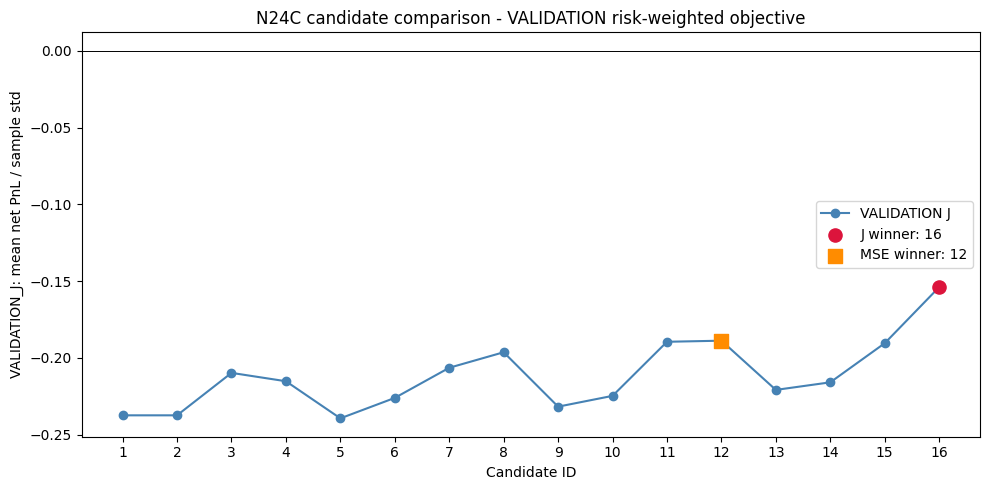

In [2]:
MIN_VALIDATION_TRADES=30
candidate=[]
for cid,(ne,lr,depth,leaf) in enumerate(GRID,1):
    r=pd.Series({'n_estimators':ne,'learning_rate':lr,'max_depth':depth,'min_samples_leaf':leaf})
    model=GradientBoostingRegressor(**params(r)).fit(c[BASE_FEATURES],c.Y_gross)
    train=model.predict(c[BASE_FEATURES]); pred=model.predict(v[BASE_FEATURES]); z=action(pred,v.c_entry_L,v.c_entry_S)
    q=econ(z,v.Y_net_L.to_numpy(),v.Y_net_S.to_numpy()); mm=metrics(v.Y_gross,pred)
    candidate.append({'candidate_id':cid,**r.to_dict(),'C_training_MSE':mean_squared_error(c.Y_gross,train),'VALIDATION_MSE':mm['MSE'],'VALIDATION_RMSE':mm['RMSE'],'VALIDATION_MAE':mm['MAE'],'VALIDATION_prediction_target_correlation':mm['correlation'],**{f'VALIDATION_{k}':val for k,val in q.items()}})
candidate_selection=pd.DataFrame(candidate)
candidate_selection['eligible_for_selection']=candidate_selection.VALIDATION_n_trade.ge(MIN_VALIDATION_TRADES)
assert len(candidate_selection)==16 and candidate_selection.eligible_for_selection.any()
candidate_selection['MSE_rank']=candidate_selection.VALIDATION_MSE.rank(method='min',ascending=True).astype(int)
candidate_selection['J_rank']=candidate_selection.VALIDATION_J.rank(method='min',ascending=False).astype(int)
order=['VALIDATION_J','VALIDATION_cumulative_net_pnl','max_depth','n_estimators','min_samples_leaf','learning_rate','candidate_id']
asc=[False,False,True,True,False,True,True]
winner=candidate_selection[candidate_selection.eligible_for_selection].sort_values(order,ascending=asc).iloc[0].copy()
candidate_selection['winner']=candidate_selection.candidate_id.eq(winner.candidate_id)
mse_winner=candidate_selection.sort_values(['VALIDATION_MSE','max_depth','n_estimators','min_samples_leaf','learning_rate','candidate_id'],ascending=[True,True,True,False,True,True]).iloc[0]
candidate_selection['J_winner_also_MSE_winner']=candidate_selection.winner & candidate_selection.candidate_id.eq(mse_winner.candidate_id)
candidate_rank_comparison=candidate_selection[['candidate_id','VALIDATION_MSE','VALIDATION_J','MSE_rank','J_rank','eligible_for_selection','winner']].sort_values('candidate_id')
assert candidate_selection.winner.sum()==1
print('N24C winner selected solely by pre-TEST risk-weighted objective, with only deterministic tie-breaks.')
print({'candidate_id':int(winner.candidate_id),'VALIDATION_J':float(winner.VALIDATION_J),'VALIDATION_MSE':float(winner.VALIDATION_MSE),'MSE_winner_candidate_id':int(mse_winner.candidate_id),'J_equals_MSE_winner':bool(winner.candidate_id==mse_winner.candidate_id)})
display(candidate_selection)
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(candidate_selection.candidate_id,candidate_selection.VALIDATION_J,marker='o',color='steelblue',label='VALIDATION J')
ax.scatter([int(winner.candidate_id)],[float(winner.VALIDATION_J)],s=90,color='crimson',zorder=3,label=f'J winner: {int(winner.candidate_id)}')
ax.scatter([int(mse_winner.candidate_id)],[float(mse_winner.VALIDATION_J)],s=90,color='darkorange',marker='s',zorder=3,label=f'MSE winner: {int(mse_winner.candidate_id)}')
ax.set_xticks(candidate_selection.candidate_id.astype(int)); ax.set_xlabel('Candidate ID'); ax.set_ylabel('VALIDATION_J: mean net PnL / sample std'); ax.set_title('N24C candidate comparison - VALIDATION risk-weighted objective'); ax.axhline(0,color='black',lw=.7); ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/'24C_candidate_validation_J_comparison.png',dpi=150); plt.show()



## Candidate-objective interpretation

The marked N24C \(J\) winner is selected by

$$
\arg\max_{\theta} J_{\mathrm{VALIDATION}}(\theta),
$$

whereas the marked MSE winner is selected by

$$
\arg\min_{\theta}
\mathrm{MSE}_{\mathrm{VALIDATION}}(\theta).
$$

The two candidates are identified using pre-TEST VALIDATION results only; neither comparison uses TEST.

## Fair BASE / HIDDEN_AWARE ablation and pre-TEST policy diagnostics

The selected BASE capacity is frozen, then used unchanged for BASE, HIDDEN_AWARE, and the three noise controls. HIDDEN_AWARE is not separately tuned.


,stage,model,MSE,RMSE,MAE,correlation
0,C,BASE,0.100970,0.317758,0.226803,0.445891
1,C,HIDDEN_AWARE,0.093791,0.306253,0.220250,0.533457
2,C,BASE_NOISE_19,0.094629,0.307618,0.220632,0.531986
3,C,BASE_NOISE_119,0.094625,0.307611,0.222176,0.541945
4,C,BASE_NOISE_219,0.095414,0.308892,0.220694,0.535679
5,VALIDATION,BASE,0.234856,0.484620,0.271714,0.029458
6,VALIDATION,HIDDEN_AWARE,0.234530,0.484283,0.274903,0.054401
7,VALIDATION,BASE_NOISE_19,0.239482,0.489369,0.274614,0.017841
8,VALIDATION,BASE_NOISE_119,0.240203,0.490105,0.275419,-0.013529
9,VALIDATION,BASE_NOISE_219,0.237228,0.487061,0.270976,0.020243


,stage,policy,n_long,n_flat,n_short,n_trade,long_share_conditional_trade,short_share_conditional_trade
0,C,FLAT,0,805,0,0,NaN,NaN
1,C,ALWAYS_LONG,805,0,0,805,1.000000,0.000000
2,C,ALWAYS_SHORT,0,0,805,805,0.000000,1.000000
3,C,BASE,89,44,672,761,0.116951,0.883049
4,C,GATE_ONLY,7,740,58,65,0.107692,0.892308
5,C,HIDDEN_AWARE,8,743,54,62,0.129032,0.870968
6,C,GATED_ALWAYS_LONG,68,737,0,68,1.000000,0.000000
7,C,GATED_ALWAYS_SHORT,0,737,68,68,0.000000,1.000000
8,VALIDATION,FLAT,0,902,0,0,NaN,NaN
9,VALIDATION,ALWAYS_LONG,902,0,0,902,1.000000,0.000000


,stage,policy,n_days,n_long,n_flat,n_short,n_trade,long_share_conditional_trade,short_share_conditional_trade,mean_daily_net_pnl,median_daily_net_pnl,std_daily_net_pnl,best_day,worst_day,mean_net_pnl_conditional_trade,median_net_pnl_conditional_trade,trade_hit_rate,cumulative_net_pnl,maximum_drawdown,J
0,C,FLAT,805,0,805,0,0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
1,C,ALWAYS_LONG,805,805,0,0,805,1.000000,0.000000,-0.120148,-0.133341,0.343981,2.212555,-0.922831,-0.120148,-0.133341,0.283230,-96.719342,-97.049690,-0.349288
2,C,ALWAYS_SHORT,805,0,0,805,805,0.000000,1.000000,0.027250,0.046232,0.347543,0.848660,-2.376311,0.027250,0.046232,0.582609,21.936271,-14.519780,0.078408
3,C,BASE,805,89,44,672,761,0.116951,0.883049,0.090851,0.057262,0.308219,2.212555,-1.552094,0.096104,0.075618,0.629435,73.135270,-2.176732,0.294762
4,C,GATE_ONLY,805,7,740,58,65,0.107692,0.892308,0.007405,0.000000,0.085937,1.088376,-0.425994,0.091704,0.034957,0.569231,5.960739,-0.862038,0.086164
5,C,HIDDEN_AWARE,805,8,743,54,62,0.129032,0.870968,0.006368,0.000000,0.090309,1.088376,-0.875229,0.082683,0.055519,0.580645,5.126340,-1.247135,0.070515
6,C,GATED_ALWAYS_LONG,805,68,737,0,68,1.000000,0.000000,-0.009732,0.000000,0.099668,1.088376,-0.726426,-0.115208,-0.108985,0.294118,-7.834153,-9.369151,-0.097643
7,C,GATED_ALWAYS_SHORT,805,0,737,68,68,0.000000,1.000000,0.000095,0.000000,0.094594,0.674889,-1.157129,0.001130,-0.001860,0.500000,0.076808,-2.583552,0.001009
8,VALIDATION,FLAT,902,0,902,0,0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
9,VALIDATION,ALWAYS_LONG,902,902,0,0,902,1.000000,0.000000,-0.015631,-0.077296,0.474533,6.470851,-0.954852,-0.015631,-0.077296,0.364745,-14.098766,-29.327064,-0.032939


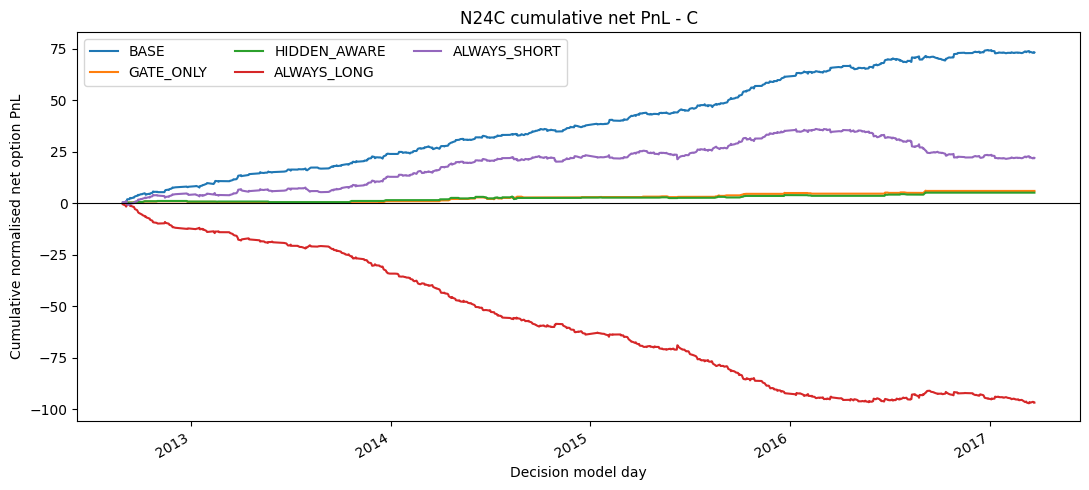

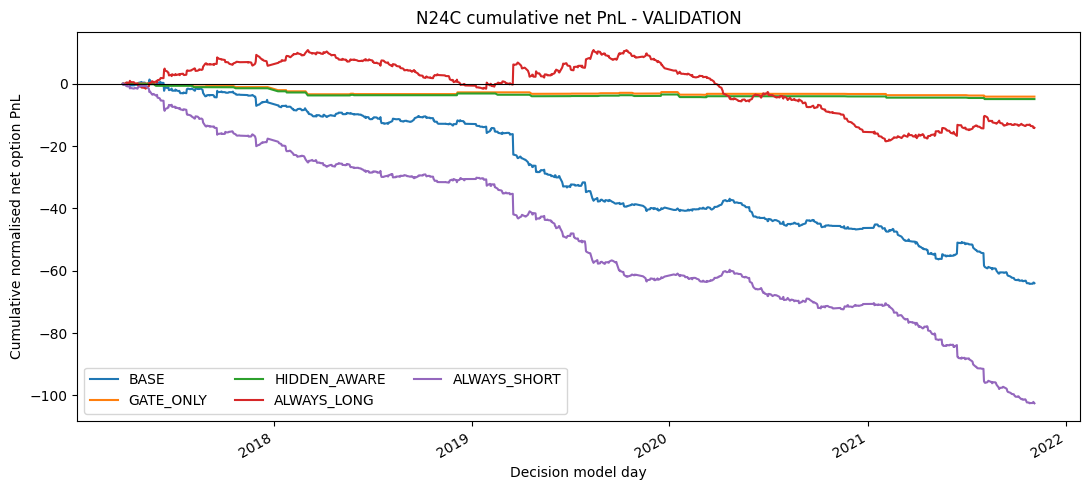

In [3]:
frozen_params=params(winner)
# C-only models using the capacity selected by BASE validation J.
base_model=GradientBoostingRegressor(**frozen_params).fit(c[BASE_FEATURES],c.Y_gross)
hidden_model=GradientBoostingRegressor(**frozen_params).fit(c[ALL_FEATURES],c.Y_gross)
for x in [c,v]:
    x['Yhat_BASE']=base_model.predict(x[BASE_FEATURES]); x['Yhat_HIDDEN_AWARE']=hidden_model.predict(x[ALL_FEATURES])
noise_map=core[['model_day']].copy(); noise_models={}; noise_rows=[]
for seed in NOISE_SEEDS:
    rng=np.random.default_rng(seed)
    for j in range(4): noise_map[f'noise_{seed}_{j+1}']=rng.standard_normal(len(noise_map))
    def noisy(x,seed):
        cols=[f'noise_{seed}_{j+1}' for j in range(4)]
        return x.merge(noise_map[['model_day']+cols].rename(columns={'model_day':'decision_model_day'}),on='decision_model_day',how='left'),cols
    cn,cols=noisy(c,seed); vn,_=noisy(v,seed)
    model=GradientBoostingRegressor(**frozen_params).fit(cn[BASE_FEATURES+cols],cn.Y_gross); noise_models[seed]=model
    c[f'Yhat_NOISE_{seed}']=model.predict(cn[BASE_FEATURES+cols]); v[f'Yhat_NOISE_{seed}']=model.predict(vn[BASE_FEATURES+cols])
    noise_rows.append({'seed':seed,**metrics(v.Y_gross,v[f'Yhat_NOISE_{seed}'])})
noise_capacity_control=pd.DataFrame(noise_rows)
pre=pd.concat([c,v],ignore_index=True).sort_values(['stage','decision_model_day']).reset_index(drop=True)
pre['G_t']=pre.episode_entry.astype(int); pre['z_BASE']=action(pre.Yhat_BASE,pre.c_entry_L,pre.c_entry_S); pre['z_GATE_ONLY']=pre.z_BASE*pre.G_t; pre['z_HIDDEN_RAW']=action(pre.Yhat_HIDDEN_AWARE,pre.c_entry_L,pre.c_entry_S); pre['z_HIDDEN_AWARE']=pre.z_HIDDEN_RAW*pre.G_t
assert (pre.z_GATE_ONLY==pre.z_BASE*pre.G_t).all() and (pre.z_HIDDEN_AWARE==pre.z_HIDDEN_RAW*pre.G_t).all()
policy={'FLAT':np.zeros(len(pre),int),'ALWAYS_LONG':np.ones(len(pre),int),'ALWAYS_SHORT':-np.ones(len(pre),int),'BASE':pre.z_BASE.to_numpy(),'GATE_ONLY':pre.z_GATE_ONLY.to_numpy(),'HIDDEN_AWARE':pre.z_HIDDEN_AWARE.to_numpy(),'GATED_ALWAYS_LONG':pre.G_t.to_numpy(),'GATED_ALWAYS_SHORT':-pre.G_t.to_numpy()}
for name,z in policy.items(): pre['z_'+name]=z
pm=[]; ac=[]; ec=[]
for stage,g in pre.groupby('stage',sort=False):
    for name,col in [('BASE','Yhat_BASE'),('HIDDEN_AWARE','Yhat_HIDDEN_AWARE')]+[(f'BASE_NOISE_{s}',f'Yhat_NOISE_{s}') for s in NOISE_SEEDS]: pm.append({'stage':stage,'model':name,**metrics(g.Y_gross,g[col])})
    for name,z in policy.items():
        zz=z[g.index]; ac.append({'stage':stage,'policy':name,**counts(zz)}); ec.append({'stage':stage,'policy':name,**econ(zz,g.Y_net_L.to_numpy(),g.Y_net_S.to_numpy())})
predictive_metrics_pretest=pd.DataFrame(pm); action_counts_pretest=pd.DataFrame(ac); economic_diagnostics_pretest=pd.DataFrame(ec)
feature_importance=pd.concat([pd.DataFrame({'model':'BASE','feature':BASE_FEATURES,'importance':base_model.feature_importances_}),pd.DataFrame({'model':'HIDDEN_AWARE','feature':ALL_FEATURES,'importance':hidden_model.feature_importances_})],ignore_index=True)
specification=pd.DataFrame([{'objective':'MAXIMISE_VALIDATION_RISK_WEIGHTED_NET_PNL_J','formula':'mean_daily_net_pnl / sample_std_daily_net_pnl','objective_population':'ALL_VALIDATION_DAYS_IN_COMMON_SAMPLE_INCLUDING_FLAT_ZERO_PNL','minimum_validation_trades':MIN_VALIDATION_TRADES,'candidate_grid':str(GRID),'selected_candidate_id':int(winner.candidate_id),'selected_hyperparameters':str(frozen_params),'GB_internal_loss':'squared_error','outer_objective_explanation':'GB fits squared-error scores internally; risk-weighted net PnL selects application capacity pre-TEST.','BASE_features':' | '.join(BASE_FEATURES),'HIDDEN_features':' | '.join(HIDDEN_FEATURES),'support_floor':SUPPORT_FLOOR,'noise_seeds':'19 | 119 | 219','gate':'frozen N22/N23 episode_entry','action_mapping':'entry-known c_entry_L/c_entry_S hurdle','C_role':'fit','VALIDATION_role':'pre-TEST J selection','TEST_role':'outcome-free handoff only','transaction_cost_source':'frozen N23 Y_net_L/Y_net_S','TEST_outcomes_loaded':'NO','TEST_economics_inspected':'NO'}])
specification.to_csv(PROCESSED/'24C_frozen_application_specification.csv',index=False)
display(predictive_metrics_pretest); display(action_counts_pretest); display(economic_diagnostics_pretest)
for stage,g in pre.groupby('stage',sort=False):
    fig,ax=plt.subplots(figsize=(11,5))
    for name in ['BASE','GATE_ONLY','HIDDEN_AWARE','ALWAYS_LONG','ALWAYS_SHORT']:
        ax.plot(g.decision_model_day,np.cumsum(net(g['z_'+name],g.Y_net_L,g.Y_net_S)),label=name)
    ax.axhline(0,color='black',lw=.8); ax.legend(ncol=3)
    ax.set_title(f'N24C cumulative net PnL - {stage}')
    ax.set_xlabel('Decision model day')
    ax.set_ylabel('Cumulative normalised net option PnL')
    fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGURES/f'24C_cumulative_net_pnl_{stage.lower()}.png',dpi=150); plt.show()



## Final C + VALIDATION refit and outcome-free TEST handoff

After the pre-TEST specification is written, models refit on C + VALIDATION only. The TEST panel contains decision-time features, frozen predictions, frozen actions, and entry-known hurdles only; realised TEST outcomes and economics are prohibited.


In [4]:
# Reload frozen N24C specification before the sole C+VALIDATION refit.
reloaded=read('24C_frozen_application_specification.csv'); assert len(reloaded)==1 and reloaded.loc[0,'objective']=='MAXIMISE_VALIDATION_RISK_WEIGHTED_NET_PNL_J'
assert len(pre)==1707
final_base=GradientBoostingRegressor(**frozen_params).fit(pre[BASE_FEATURES],pre.Y_gross); final_hidden=GradientBoostingRegressor(**frozen_params).fit(pre[ALL_FEATURES],pre.Y_gross); final_noise={}
for seed in NOISE_SEEDS:
    q,cols=noisy(pre,seed); final_noise[seed]=GradientBoostingRegressor(**frozen_params).fit(q[BASE_FEATURES+cols],q.Y_gross)
forbidden={'Y_gross','Y_net_L','Y_net_S','Pi_gross','Pi_net','realised_net_pnl','future_hedge_cost','payoff_T','hedge_pnl_mid'}
test_contract=read('23_contract_admissibility_panel.csv',parse_dates=['model_day'],usecols=['model_day','stage','contract_admissible','episode_entry','Delta_L','common_log_response','P_R','P_I_prev'])
test_contract=test_contract[test_contract.stage.eq('TEST') & test_contract.contract_admissible.fillna(False)].copy()
test_cost=read('23_cost_grid_panel.csv',parse_dates=['model_day'],usecols=['model_day','stage','s_sigma_label','c_entry_L','c_entry_S'])
test_cost=test_cost[test_cost.stage.eq('TEST') & test_cost.s_sigma_label.eq('BASE')].drop(columns='s_sigma_label')
test_contract=test_contract.merge(test_cost,on=['model_day','stage'],how='left',validate='one_to_one')
test_panel=features(test_contract,False).sort_values('decision_model_day').reset_index(drop=True); test=test_panel[test_panel.COMMON_complete].copy(); test['G_t']=test.episode_entry.astype(int)
assert not forbidden.intersection(test_contract.columns) and not forbidden.intersection(test_panel.columns) and not forbidden.intersection(test.columns)
test['Yhat_BASE']=final_base.predict(test[BASE_FEATURES]); test['Yhat_HIDDEN_AWARE']=final_hidden.predict(test[ALL_FEATURES])
for seed,model in final_noise.items(): q,cols=noisy(test,seed); test[f'Yhat_NOISE_{seed}']=model.predict(q[BASE_FEATURES+cols])
test['z_BASE']=action(test.Yhat_BASE,test.c_entry_L,test.c_entry_S); test['z_GATE_ONLY']=test.z_BASE*test.G_t; test['z_HIDDEN_RAW']=action(test.Yhat_HIDDEN_AWARE,test.c_entry_L,test.c_entry_S); test['z_HIDDEN_AWARE']=test.z_HIDDEN_RAW*test.G_t
assert (test.z_GATE_ONLY==test.z_BASE*test.G_t).all() and (test.z_HIDDEN_AWARE==test.z_HIDDEN_RAW*test.G_t).all()
handoff=test[['decision_model_day','forecast_target_model_day','stage','G_t','c_entry_L','c_entry_S','R_model_support','I_model_support','Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219','z_BASE','z_GATE_ONLY','z_HIDDEN_RAW','z_HIDDEN_AWARE']].copy()
availability=pd.DataFrame([{'stage':'TEST','N23_admissible':len(test_panel),'COMMON_complete':len(test),'gate_entries_surviving_COMMON':int(test.G_t.sum()),'R_support_ge_3':int((test_panel.R_model_support>=3).sum()),'I_support_ge_3':int((test_panel.I_model_support>=3).sum()),'TEST_outcomes_loaded':'NO','TEST_economics_inspected':'NO'}])
# exports and genuine closure.
exports={'24C_application_common_feature_panel_pretest.csv':pre,'24C_risk_weighted_candidate_selection.csv':candidate_selection,'24C_candidate_rank_comparison.csv':candidate_rank_comparison,'24C_noise_capacity_control.csv':noise_capacity_control,'24C_predictive_metrics_pretest.csv':predictive_metrics_pretest,'24C_policy_actions_pretest.csv':action_counts_pretest,'24C_economic_diagnostics_pretest.csv':economic_diagnostics_pretest,'24C_feature_importance.csv':feature_importance,'24C_final_refit_manifest.csv':pd.DataFrame([{'refit_rows':len(pre),'selected_candidate_id':int(winner.candidate_id),'parameters':str(frozen_params)}]),'24C_test_feature_availability_audit.csv':availability,'24C_test_prediction_policy_handoff.csv':handoff,'24C_test_firewall_audit.csv':pd.DataFrame([{'object':'test_working_objects','forbidden_outcomes_present':'EMPTY','TEST_outcomes_loaded':'NO','TEST_economics_inspected':'NO'}])}
for name,df in exports.items(): df.to_csv(PROCESSED/name,index=False)
manifest=pd.DataFrame([{'file':name,'rows':len(df),'exists':(PROCESSED/name).exists()} for name,df in exports.items()])
figure_manifest=pd.DataFrame([{'file':name,'rows':np.nan,'exists':(FIGURES/name).exists()} for name in ['24C_cumulative_net_pnl_c.png','24C_cumulative_net_pnl_validation.png','24C_candidate_validation_J_comparison.png']])
manifest=pd.concat([manifest,figure_manifest],ignore_index=True); assert manifest.exists.all(); manifest.to_csv(PROCESSED/'24C_export_manifest.csv',index=False)
up_after={path.name:file_hash(path) for path in UPSTREAM_NOTEBOOKS}; assert UPSTREAM_HASH_BEFORE==up_after
assert len(c)==805 and len(v)==902 and len(pre)==1707 and int(c.episode_entry.sum())==68 and int(v.episode_entry.sum())==34 and len(handoff)==901
print('N24C CLOSURE',{'C_common':len(c),'VALIDATION_common':len(v),'selected_candidate_id':int(winner.candidate_id),'selected_hyperparameters':dict(winner[['n_estimators','learning_rate','max_depth','min_samples_leaf']]),'selected_VALIDATION_J':float(winner.VALIDATION_J),'selected_VALIDATION_cumulative_net_pnl':float(winner.VALIDATION_cumulative_net_pnl),'selected_VALIDATION_trade_count':int(winner.VALIDATION_n_trade),'selected_VALIDATION_MSE':float(winner.VALIDATION_MSE),'MSE_winner_candidate_id':int(mse_winner.candidate_id),'J_winner_equals_MSE_winner':bool(winner.candidate_id==mse_winner.candidate_id),'BASE_VALIDATION_J':float(economic_diagnostics_pretest.query("stage=='VALIDATION' and policy=='BASE'").J.iloc[0]),'GATE_ONLY_VALIDATION_J':float(economic_diagnostics_pretest.query("stage=='VALIDATION' and policy=='GATE_ONLY'").J.iloc[0]),'HIDDEN_VALIDATION_J':float(economic_diagnostics_pretest.query("stage=='VALIDATION' and policy=='HIDDEN_AWARE'").J.iloc[0]),'FLAT_VALIDATION_cumulative_net_pnl':float(economic_diagnostics_pretest.query("stage=='VALIDATION' and policy=='FLAT'").cumulative_net_pnl.iloc[0]),'final_refit_rows':len(pre),'TEST_handoff_rows':len(handoff),'TEST_gate_rows':int(test.G_t.sum()),'TEST_outcomes_loaded':'NO','TEST_economics_inspected':'NO','execution_errors':0})

print('N24C presentation verification')
print({'C cumulative PnL figure created':'YES','VALIDATION cumulative PnL figure created':'YES','Candidate J comparison figure created':'YES','Opening LaTeX renders correctly':'YES','Selected candidate unchanged':'YES','Selected hyperparameters unchanged':'YES','Selected VALIDATION J unchanged':'YES','TEST outcomes loaded':'NO','TEST economics inspected':'NO','execution errors':0})


N24C CLOSURE {'C_common': 805, 'VALIDATION_common': 902, 'selected_candidate_id': 16, 'selected_hyperparameters': {'n_estimators': np.float64(250.0), 'learning_rate': np.float64(0.05), 'max_depth': np.float64(2.0), 'min_samples_leaf': np.float64(40.0)}, 'selected_VALIDATION_J': -0.15393138802563103, 'selected_VALIDATION_cumulative_net_pnl': -63.973932139459336, 'selected_VALIDATION_trade_count': 783, 'selected_VALIDATION_MSE': 0.2348560885998679, 'MSE_winner_candidate_id': 12, 'J_winner_equals_MSE_winner': False, 'BASE_VALIDATION_J': -0.15393138802563103, 'GATE_ONLY_VALIDATION_J': -0.06425286487316263, 'HIDDEN_VALIDATION_J': -0.07520210411516928, 'FLAT_VALIDATION_cumulative_net_pnl': 0.0, 'final_refit_rows': 1707, 'TEST_handoff_rows': 901, 'TEST_gate_rows': 74, 'TEST_outcomes_loaded': 'NO', 'TEST_economics_inspected': 'NO', 'execution_errors': 0}
N24C presentation verification
{'C cumulative PnL figure created': 'YES', 'VALIDATION cumulative PnL figure created': 'YES', 'Candidate J com